# Notebook 3: Building the Knowledge Graph

In this notebook, we load the course data and MIT topic hierarchy into Neo4j in order to create the knowledge graph described in the schema.

**Steps:**
1. Connect to Neo4j
2. Set up constraints and indexes
3. Create Course, Topic, and Instructor nodes
4. Create relationships: HAS_TOPIC, TAUGHT_BY, CHILD_OF, and RELATED_TO
5. Verify the graph

---
## Setup

In [1]:
import pandas as pd
import os
from dotenv import load_dotenv
from neo4j import GraphDatabase
from itertools import combinations
from collections import Counter
from pathlib import Path
from IPython.display import Image

load_dotenv(dotenv_path='../.env')
PROJECT_ROOT = Path('..')

In [2]:
NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', '')

if not NEO4J_PASSWORD:
    raise ValueError(
        'NEO4J_PASSWORD not set. '
        'Export it as an environment variable or create a .env file.'
    )

In [3]:
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# Quick connection test
with driver.session() as session:
    result = session.run('RETURN 1 AS connected')
    print(f'Connected to Neo4j at {NEO4J_URI}: {result.single()["connected"] == 1}')

Connected to Neo4j at bolt://localhost:7687: True


---
## Load source data

In [4]:
courses_df = pd.read_csv(PROJECT_ROOT / 'data' / 'curated' / 'courses.csv')
hierarchy_df = pd.read_csv(PROJECT_ROOT / 'data' / 'curated' / 'topic_hierarchy.csv', sep=';')

print(f'{len(courses_df)} courses')
print(f'{len(hierarchy_df)} parent-child topic pairs')

50 courses
99 parent-child topic pairs


---
## Clear existing data

Start fresh each time this notebook runs.

In [5]:
with driver.session() as session:
    session.execute_write(lambda tx: tx.run('MATCH (n) DETACH DELETE n'))
print('Database cleared')

Database cleared


---
## Constraints and indexes

Uniqueness constraints also create indexes automatically.

In [6]:
constraints = [
    'CREATE CONSTRAINT course_title IF NOT EXISTS FOR (c:Course) REQUIRE c.title IS UNIQUE',
    'CREATE CONSTRAINT topic_name IF NOT EXISTS FOR (t:Topic) REQUIRE t.name IS UNIQUE',
    'CREATE CONSTRAINT instructor_name IF NOT EXISTS FOR (i:Instructor) REQUIRE i.name IS UNIQUE',
]

for cypher in constraints:
    driver.execute_query(cypher)

print('Constraints created')

Constraints created


---
## Create Topic nodes

The topics come from two sources: the course CSV (only the 44 topics that appear in our data) and the hierarchy CSV (which includes the full MIT taxonomy). We create nodes for every topic in our data, tagged with their level (parent or child).

In [7]:
# Collect all parent and child names from the hierarchy
parents_in_hierarchy = set(hierarchy_df['parent'].unique())
children_in_hierarchy = set(hierarchy_df['child'].unique())

# Collect topics that actually appear in our course data
our_topics = set()
for topics_str in courses_df['topics']:
    for t in topics_str.split(';'):
        t = t.strip()
        if t:
            our_topics.add(t)

print(f'{len(our_topics)} topics in course data')

# Build batch: list of {name, level} dicts
topic_batch = []
for topic in our_topics:
    if topic in parents_in_hierarchy:
        level = 'parent'
    elif topic in children_in_hierarchy:
        level = 'child'
    else:
        level = 'unknown'
    topic_batch.append({'name': topic, 'level': level})

# Single UNWIND query to create all topic nodes
with driver.session() as session:
    session.execute_write(lambda tx: tx.run(
        '''
        UNWIND $topics AS t
        MERGE (topic:Topic {name: t.name})
        SET topic.level = t.level
        ''',
        topics=topic_batch
    ))

print('Topic nodes created')

44 topics in course data
Topic nodes created


---
## Create CHILD_OF relationships

This step is carried out only for topics that exist in our graph.

In [8]:
# Build batch of parent-child pairs
child_of_batch = [
    {'child': row['child'], 'parent': row['parent']}
    for _, row in hierarchy_df.iterrows()
    if row['parent'] in our_topics and row['child'] in our_topics
]

with driver.session() as session:
    session.execute_write(lambda tx: tx.run(
        '''
        UNWIND $pairs AS pair
        MATCH (child:Topic {name: pair.child})
        MATCH (parent:Topic {name: pair.parent})
        MERGE (child)-[:CHILD_OF]->(parent)
        ''',
        pairs=child_of_batch
    ))

print(f'{len(child_of_batch)} CHILD_OF relationships created')

34 CHILD_OF relationships created


---
## Create Course nodes

In [9]:
# Build batch of course records
course_batch = [
    {
        'title': row['title'],
        'description': row['description'],
        'url': row['url'],
        'course_number': row['course_number'],
        'availability': row['availability'],
        'year': int(row['year']),
    }
    for _, row in courses_df.iterrows()
]

with driver.session() as session:
    session.execute_write(lambda tx: tx.run(
        '''
        UNWIND $courses AS c
        CREATE (course:Course {
            title: c.title,
            description: c.description,
            url: c.url,
            course_number: c.course_number,
            availability: c.availability,
            year: c.year
        })
        ''',
        courses=course_batch
    ))

print(f'{len(course_batch)} Course nodes created')

50 Course nodes created


---
## Create Instructor nodes and TAUGHT_BY relationships

In [10]:
# Build batch: one entry per course-instructor pair
taught_by_batch = []
for _, row in courses_df.iterrows():
    for instructor in row['instructors'].split(';'):
        instructor = instructor.strip()
        if instructor:
            taught_by_batch.append({'title': row['title'], 'name': instructor})

with driver.session() as session:
    session.execute_write(lambda tx: tx.run(
        '''
        UNWIND $pairs AS pair
        MATCH (c:Course {title: pair.title})
        MERGE (i:Instructor {name: pair.name})
        MERGE (c)-[:TAUGHT_BY]->(i)
        ''',
        pairs=taught_by_batch
    ))

# Count unique instructors
result = driver.execute_query('MATCH (i:Instructor) RETURN count(i) AS n')
instructor_count = result.records[0]['n']

print(f'{instructor_count} Instructor nodes created')
print(f'{len(taught_by_batch)} TAUGHT_BY relationships created')

70 Instructor nodes created
87 TAUGHT_BY relationships created


---
## Create HAS_TOPIC relationships

In [11]:
# Build batch: one entry per course-topic pair
has_topic_batch = []
for _, row in courses_df.iterrows():
    for topic in row['topics'].split(';'):
        topic = topic.strip()
        if topic:
            has_topic_batch.append({'title': row['title'], 'topic': topic})

with driver.session() as session:
    session.execute_write(lambda tx: tx.run(
        '''
        UNWIND $pairs AS pair
        MATCH (c:Course {title: pair.title})
        MATCH (t:Topic {name: pair.topic})
        MERGE (c)-[:HAS_TOPIC]->(t)
        ''',
        pairs=has_topic_batch
    ))

print(f'{len(has_topic_batch)} HAS_TOPIC relationships created')

387 HAS_TOPIC relationships created


---
## Compute and create RELATED_TO relationships

Co-occurrence between child-level topics, weighted by how many courses
share both topics. Restricted to child-level topics only.

In [12]:
# Compute co-occurrence counts
pair_counts = Counter()

for _, row in courses_df.iterrows():
    topics = [t.strip() for t in row['topics'].split(';') if t.strip()]
    # Keep only child-level topics
    child_topics = sorted(set(t for t in topics if t in children_in_hierarchy))
    for a, b in combinations(child_topics, 2):
        pair_counts[(a, b)] += 1

print(f'{len(pair_counts)} topic pairs with co-occurrence')

# Build batch
related_batch = [
    {'a': a, 'b': b, 'weight': weight}
    for (a, b), weight in pair_counts.items()
]

with driver.session() as session:
    session.execute_write(lambda tx: tx.run(
        '''
        UNWIND $pairs AS pair
        MATCH (t1:Topic {name: pair.a})
        MATCH (t2:Topic {name: pair.b})
        MERGE (t1)-[r:RELATED_TO]->(t2)
        SET r.weight = pair.weight
        ''',
        pairs=related_batch
    ))

print(f'{len(pair_counts)} RELATED_TO relationships created')

161 topic pairs with co-occurrence
161 RELATED_TO relationships created


---
## Verify the graph

In [13]:
result = driver.execute_query('''
    MATCH (n)
    RETURN labels(n)[0] AS label, count(n) AS count
    ORDER BY count DESC
''')

print('Node counts:')
for record in result.records:
    print(f'  {record["label"]}: {record["count"]}')

Node counts:
  Instructor: 70
  Course: 50
  Topic: 44


In [14]:
result = driver.execute_query('''
    MATCH ()-[r]->()
    RETURN type(r) AS type, count(r) AS count
    ORDER BY count DESC
''')

print('Relationship counts:')
for record in result.records:
    print(f'  {record["type"]}: {record["count"]}')

Relationship counts:
  HAS_TOPIC: 387
  RELATED_TO: 161
  TAUGHT_BY: 87
  CHILD_OF: 34


## Graph Visualization

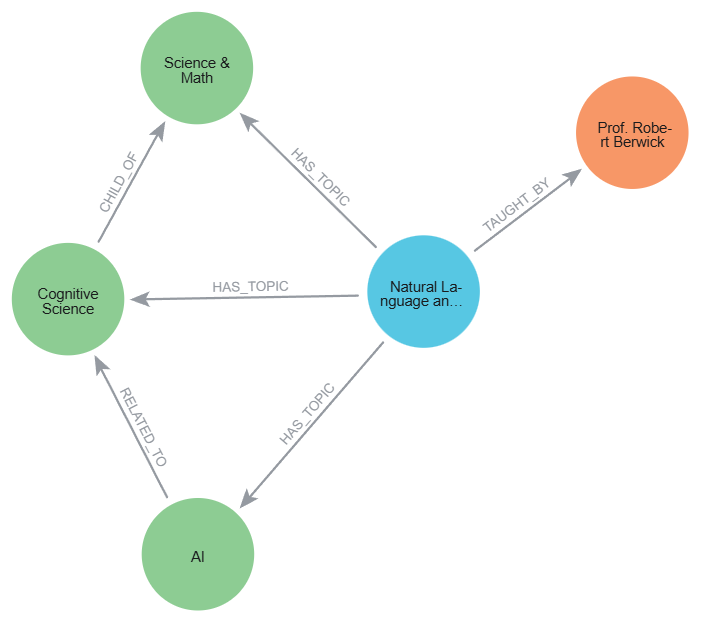

In [15]:
Image(filename=str(PROJECT_ROOT / 'schema' / 'sample-subgraph.png'), width=600)

**Figure 1:** A sample subgraph showing all node and relationship types in action: a course _(Natural Language and the Computer Representation of Knowledge)_ connected to its instructor, parent topic, and child topics,
with CHILD_OF and RELATED_TO linking the topics together.

### Sample queries

In [16]:
# Which topics does 'Deep Learning' cover?
result = driver.execute_query('''
    MATCH (c:Course {title: 'Deep Learning'})-[:HAS_TOPIC]->(t:Topic)
    RETURN t.name AS topic, t.level AS level
    ORDER BY t.level, t.name
''')

print('Deep Learning topics:')
for record in result.records:
    print(f'  [{record["level"]}] {record["topic"]}')

Deep Learning topics:
  [child] AI
  [child] Computer Science
  [child] Machine Learning
  [child] Visualization
  [parent] Data Science, Analytics & Computer Technology
  [parent] Engineering


In [17]:
# Which child topics are most connected via RELATED_TO?
result = driver.execute_query('''
    MATCH (t:Topic)-[r:RELATED_TO]-()
    WHERE t.level = 'child'
    RETURN t.name AS topic, sum(r.weight) AS total_weight, count(r) AS connections
    ORDER BY total_weight DESC
    LIMIT 10
''')

print('Most connected child topics (by co-occurrence weight):')
for record in result.records:
    print(f'  {record["topic"]}: weight={record["total_weight"]}, connections={record["connections"]}')

Most connected child topics (by co-occurrence weight):
  Machine Learning: weight=193, connections=33
  AI: weight=193, connections=33
  Computer Science: weight=193, connections=33
  Electrical Engineering: weight=51, connections=13
  Cognitive Science: weight=51, connections=14
  Algorithms and Data Structures: weight=38, connections=11
  Software Design and Engineering: weight=22, connections=8
  Philosophy: weight=22, connections=10
  Systems Engineering: weight=17, connections=9
  Psychology: weight=16, connections=8


In [18]:
# Instructors who teach the most courses
result = driver.execute_query('''
    MATCH (i:Instructor)<-[:TAUGHT_BY]-(c:Course)
    WITH i, count(c) AS courses
    WHERE courses > 1
    RETURN i.name AS instructor, courses
    ORDER BY courses DESC
''')

print('Instructors teaching multiple courses:')
for record in result.records:
    print(f'  {record["instructor"]}: {record["courses"]}')

Instructors teaching multiple courses:
  Prof. Leslie Kaelbling: 4
  Prof. Tomás Lozano-Pérez: 3
  Prof. Vincent Sitzmann: 2
  Patrick Henry Winston: 2
  Prof. Tomaso Poggio: 2
  Prof. Brian Charles Williams: 2
  Prof. Henry Lieberman: 2
  MIT RAISE: 2
  Prof. Bernhardt Trout: 2
  Prof. Isaac Chuang: 2
  Prof. Lucila Ohno-Machado: 2
  Prof. Peter Szolovits: 2
  Prof. Cynthia Breazeal: 2
  Prof. Russell Tedrake: 2


---
## Close connection

In [19]:
driver.close()
print('Connection closed')

Connection closed


---
## Next Steps

Now that the knowledge graph is built, in the next notebook, we'll implement both a naive RAG and a Graph RAG pipeline, run the same queries through each, and compare the results.